In [22]:

import pandas as pd
import numpy as np
df = pd.read_csv('C:\\Users\\Anu A\\Desktop\\FE\\mpg.csv')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [24]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   name          398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


,mpg,cylinders,displacement,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [44]:
df.drop_duplicates()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger


In [27]:
print(df['mpg'].isnull().sum())
print(df['horsepower'].isnull().sum())


0
0


In [28]:
# Convert horsepower to numeric
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')



In [29]:
# Handle missing values
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

In [ ]:
Q1 = df['horsepower'].quantile(0.25)
Q3 = df['horsepower'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['horsepower'] < lower_bound) | (df['horsepower'] > upper_bound)]

print("Number of outliers:", outliers.shape[0])


Number of outliers: 11


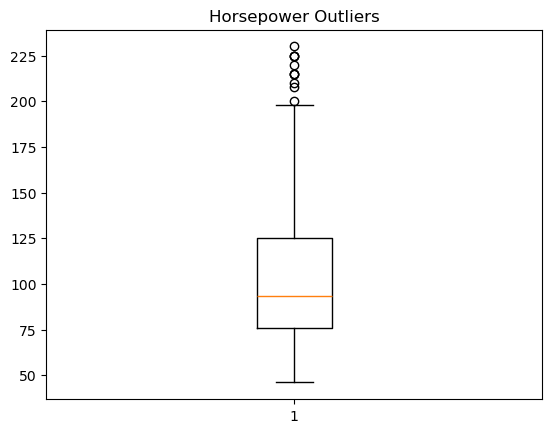

In [31]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df['horsepower'])
plt.title("Horsepower Outliers")
plt.show()


In [32]:
X = df[['horsepower']]   
Y = df['mpg']

slope(w): -0.15816020313402757
intercept(b): 40.01131787111278


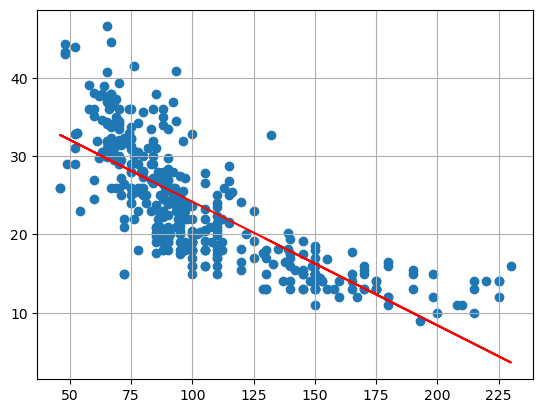

In [55]:
import numpy as np
import matplotlib.pyplot as plt

y_mean=np.mean(y)
x_mean=np.mean(x)

numerator=np.sum((x-x_mean)*(y-y_mean))
denominator=np.sum((x-x_mean)**2)

w=numerator/denominator
b=y_mean-w*x_mean

y_pred=w*x+b

print("slope(w):",w)
print("intercept(b):",b)

plt.scatter(x,y)
plt.plot(x,y_pred,color='red')
plt.grid(True)
plt.show()

In [56]:
import numpy as np
from sklearn.linear_model import LinearRegression

model = LinearRegression()
x = df[['horsepower']]
y = df['mpg']
model.fit(x,y)

print("intercept", model.intercept_)
print("slope:", model.coef_[0])

intercept 40.01131787111278
slope: -0.1581602031340276
